# DenseNet training
This notebook trains an DenseNet model for multi-class classification on the ERCP dataset.

In [1]:
from livelossplot import PlotLosses 
from livelossplot.outputs import MatplotlibPlot

%matplotlib inline
import matplotlib.pyplot as plt

from monai.transforms import (Activations, AsDiscrete, LoadImage, EnsureChannelFirst, Resize,
                                RandZoom, RandAdjustContrast, RandGaussianNoise, RandRotate,
                                ToTensor, Compose, NormalizeIntensity, Lambda)
from monai.data import decollate_batch, DataLoader
from monai.metrics import ROCAUCMetric
from monai.utils import set_determinism
from monai.config import print_config
from monai.networks.nets import DenseNet121

import numpy as np

import os

from PIL import Image

import random

import seaborn as sns

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

import time

import torch
from torch.utils.data import Dataset
import torch.nn as nn
from torchmetrics.classification import MulticlassF1Score


np.random.seed(0)
set_determinism(seed=0)
print_config()

MONAI version: 1.5.2
Numpy version: 1.26.4
Pytorch version: 2.5.1+cu121
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: c:\Users\<username>\Desktop\Uni\MIA\Aprendizagem Profunda\Módulo II\Aprendizagem-Profunda---Trabalho-Pratico\venv\Lib\site-packages\monai\__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: NOT INSTALLED or UNKNOWN VERSION.
scikit-image version: NOT INSTALLED or UNKNOWN VERSION.
scipy version: 1.17.1
Pillow version: 12.1.0
Tensorboard version: NOT INSTALLED or UNKNOWN VERSION.
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.20.1+cu121
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 7.2.2
pandas version: 2.3.3
einops version: NOT INSTALLED or UNKNOWN VERSION.
transformers version: NOT INSTALLED or UNKNOWN VERS

In [2]:
model_name = './models/densenet.pth'

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


In [4]:
import os
import pandas as pd
import shutil
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# 1. Definir os caminhos
base_dir = '../dataset' 
processed_dir = os.path.join(base_dir, 'processed')
metadata_path = os.path.join(base_dir, 'metadata.csv')

# Ler o CSV
df = pd.read_csv(metadata_path)

# ==============================================================================
# FASE 1: LIMPEZA DE DADOS E MAPEAMENTO DE CLASSES
# ==============================================================================
print(f"Total de imagens original: {len(df)}")

# 1. Remover o lixo
df = df[(df['Keep'] == 'Keep') & (df['Label'] != 'Unlabelled')].copy()

# 2. O Dicionário Mágico: Traduzir o CSV para o formato do teu Enunciado
mapeamento_classes = {
    'Normal': 'Normal',
    'Lithiasis': 'Lithiasis',
    'Biliary Leaks': 'Biliary_Leaks',          # Tirar o espaço
    'Malignant Stricture': 'Stricture',        # Fundir as duas estenoses
    'Benign Stricture': 'Stricture'
}

# Aplicar o mapeamento (o que não estiver no dicionário vira NaN, mas não temos mais nada)
df['Label'] = df['Label'].map(mapeamento_classes)

# Garantir que só trabalhamos com as 4 classes pedidas (por segurança)
classes_alvo = ['Biliary_Leaks', 'Lithiasis', 'Stricture', 'Normal']
df = df[df['Label'].isin(classes_alvo)].copy()

print(f"Total de imagens após limpeza e fusão de classes: {len(df)}")
# Mostrar as quantidades de cada classe para confirmares que o desbalanceamento existe!
print("\nDistribuição das classes:")
print(df['Label'].value_counts())

# ==============================================================================
# FASE 2: SPLIT (Treino, Validação, Teste)
# ==============================================================================
# Dividir primeiro em 80% Treino e 20% (Temp)
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['Label'], random_state=42)

# Dividir os 20% Temp em 10% Validação e 10% Teste
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['Label'], random_state=42)

# Assinalar a que split pertence cada linha
train_df['split'] = 'train'
val_df['split'] = 'val'
test_df['split'] = 'test'

# Juntar tudo num DataFrame final
df_final = pd.concat([train_df, val_df, test_df])

# ==============================================================================
# FASE 3: CRIAR PASTAS E COPIAR
# ==============================================================================
phases = ['train', 'val', 'test']
classes = df_final['Label'].unique()

# Criar diretorias
for phase in phases:
    for cls in classes:
        os.makedirs(os.path.join(base_dir, phase, str(cls)), exist_ok=True)

# Copiar imagens
print("A organizar as imagens nas pastas corretas...")
erros = 0

for index, row in tqdm(df_final.iterrows(), total=df_final.shape[0]):
    filename = os.path.basename(str(row['processed_image_path']))
    img_class = str(row['Label'])
    img_split = str(row['split'])
    
    src = os.path.join(processed_dir, filename)
    dst = os.path.join(base_dir, img_split, img_class, filename)
    
    if os.path.exists(src):
        shutil.copy2(src, dst)
    else:
        erros += 1

print(f"\nOrganização concluída! Ficheiros não encontrados: {erros}")

Total de imagens original: 19317
Total de imagens após limpeza e fusão de classes: 1568

Distribuição das classes:
Label
Lithiasis        726
Stricture        392
Normal           299
Biliary_Leaks    151
Name: count, dtype: int64
A organizar as imagens nas pastas corretas...


100%|██████████| 1568/1568 [00:05<00:00, 267.39it/s]


Organização concluída! Ficheiros não encontrados: 0


## Dataset
Load dataset paths and compute class counts. This section populates `data` with `train`, `val`, and `test` image file lists and their labels.

In [5]:
base_dir = '../dataset'
phases = ['train', 'val', 'test']

data = {phase: {'images': [], 'labels': []} for phase in phases}
class_names = sorted([x for x in os.listdir(os.path.join(base_dir, 'train')) if os.path.isdir(os.path.join(base_dir, 'train', x))])
#class_names = sorted([x for x in os.listdir(os.path.join(base_dir, 'train')) if os.path.isdir(os.path.join(base_dir, 'train', x))])
num_class = len(class_names)

def load_images_labels(phase):
    for i, class_name in enumerate(class_names):
        class_dir = os.path.join(base_dir, phase, class_name)
        valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
        image_files = [
                            os.path.join(class_dir, x)
                            for x in os.listdir(class_dir)
                            if x.lower().endswith(valid_exts)
                        ]

        data[phase]['images'].extend(image_files)
        data[phase]['labels'].extend([i] * len(image_files))

for phase in phases:
    load_images_labels(phase)

for phase in phases:
    print(f"{phase.capitalize()} count =", len(data[phase]['images']))
    

Train count = 1400
Val count = 244
Test count = 246


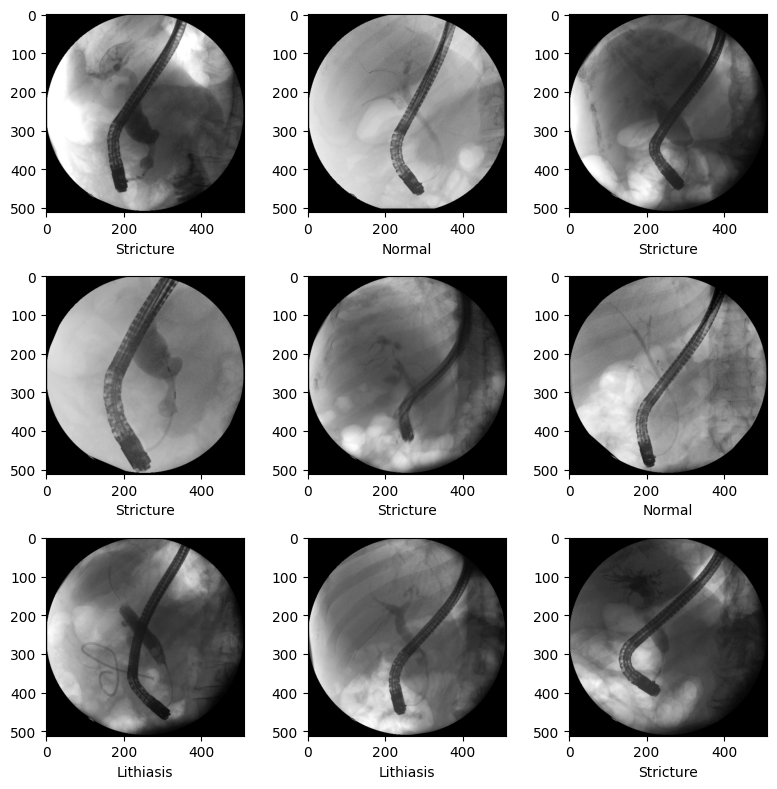

In [6]:
plt.subplots(3, 3, figsize=(8, 8))
for i, k in enumerate(np.random.randint(len(data['train']['images']), size=9)):
    im = Image.open(data['train']['images'][k])
    arr = np.array(im)
    plt.subplot(3, 3, i + 1)
    plt.xlabel(class_names[data['train']['labels'][k]])
    plt.imshow(arr, cmap='gray', vmin=0, vmax=255)
plt.tight_layout()
plt.show()


----- TRAIN CASES -----
cases: 1400
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[121 682 284 313]
1400


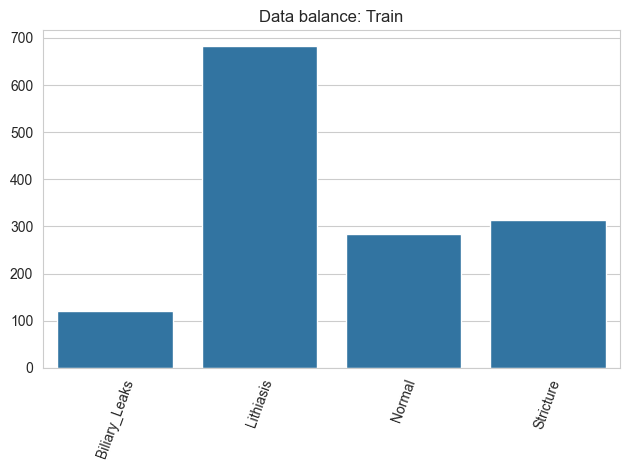

----- VALIDATION CASES -----
cases: 244
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[ 15 134  55  40]
244


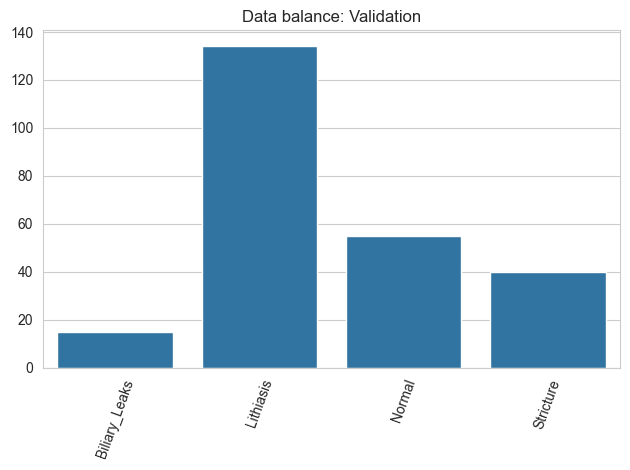

----- TEST CASES -----
cases: 246
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[ 15 136  56  39]
246


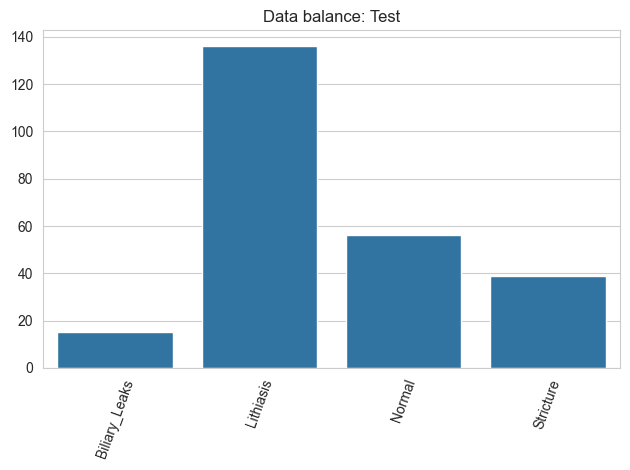

In [7]:
def visualize_holdout_balance(labels, class_names, header):
    sns.set_style('whitegrid')
    print("cases:", len(labels))
    x, y = np.unique(labels, return_counts=True)
    x_ext=[class_names[n]  for n in x]
    print(x_ext)
    print([str(n) for n in x])
    print(y)
    print(np.sum(y))
    grafico=sns.barplot(x=x_ext, y=y)
    grafico.set_title(f'Data balance: {header}')
    plt.xticks(rotation=70)
    plt.tight_layout()
    plt.show()

print("----- TRAIN CASES -----")
visualize_holdout_balance(data['train']['labels'], class_names, 'Train')
print("----- VALIDATION CASES -----")
visualize_holdout_balance(data['val']['labels'], class_names, 'Validation')
print("----- TEST CASES -----")
visualize_holdout_balance(data['test']['labels'], class_names, 'Test')


## Transforms
Define data augmentation and preprocessing for training and validation. Images are resized to 512×512.

In [8]:
class EnsureSingleChannel:
    def __call__(self, img):
        if img.shape[0] == 3:
            img = img.mean(dim=0, keepdim=True)
        return img

def repeat_if_needed(img):
    if img.shape[0] == 1:
        return img.repeat(3, 1, 1)
    return img
    
train_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((512, 512)),
    RandRotate(range_x=15, prob=0.5),
    RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5),
    RandAdjustContrast(prob=0.5),
    RandGaussianNoise(prob=0.3, mean=0.0, std=0.01),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

val_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((512, 512)),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

act = Activations(softmax=True)
to_onehot = AsDiscrete(to_onehot=num_class)

## Dataset & DataLoaders
Wrap file paths into a Dataset and create DataLoaders for training, validation and testing.

In [9]:
class MedNISTDataset(Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        image = self.image_files[index]
        return self.transforms(image), self.labels[index]

train_ds = MedNISTDataset(data['train']['images'], data['train']['labels'], train_transforms)
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=0)

val_ds = MedNISTDataset(data['val']['images'], data['val']['labels'], val_transforms)
val_loader = DataLoader(val_ds, batch_size=4, num_workers=0)

test_ds = MedNISTDataset(data['test']['images'], data['test']['labels'], val_transforms)
test_loader = DataLoader(test_ds, batch_size=4, num_workers=0)

## Model
Instantiate an DenseNet backbone (pretrained) and adapt the classifier head to the number of classes.

In [10]:
device = torch.device("cuda:0")
model = DenseNet121(
    spatial_dims=2,             # 2D images
    in_channels=3,   
    out_channels=num_class,  
    pretrained=True 
).to(device)

C:\Users\bruno\AppData\Local\Temp\ipykernel_30824\134357258.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('densenet.pth'))


DenseNet (Treinada) configurada como Extrator de Features.

A extrair features do conjunto de Treino (isto pode demorar uns minutos)...
A extrair features do conjunto de Validação...
Extração concluída em 55.17 segundos!

A iniciar o Grid Search para encontrar os melhores hiperparâmetros...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

Grid Search concluído em 17.48 minutos!

🏆 MELHORES PARÂMETROS ENCONTRADOS:
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}

 🚀 F1-SCORE MACRO ALCANÇADO (OTIMIZADO): 0.9067 

Relatório de Classificação Detalhado:
               precision    recall  f1-score   support

Biliary_Leaks       1.00      0.93      0.97        15
    Lithiasis       0.96      0.87      0.91       134
       Normal       0.85      0.95      0.90        55
    Stricture       0.79      0.93      0.85        40

     accuracy                           0.90       244
    macro avg       0.90      0.92      0.91       244
 weighted avg       0.91      0.9

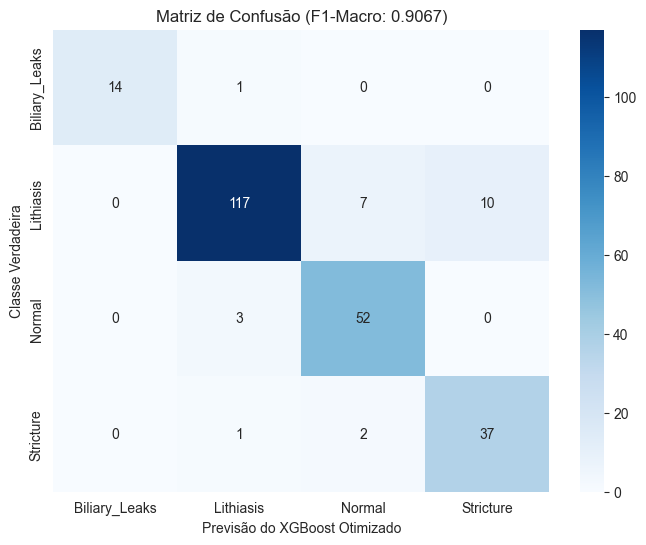

In [ ]:
from monai.networks.nets import DenseNet121
from sklearn.model_selection import GridSearchCV
import torch
import torch.nn as nn
import numpy as np
import time
import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# FASE 1: PREPARAR A DENSENET (MONAI) COMO EXTRATOR DE FEATURES
# ==============================================================================
model = DenseNet121(spatial_dims=2, in_channels=3, out_channels=4)
model.load_state_dict(torch.load('densenet.pth'))

# Cortar a cabeça - No MONAI chama-se 'class_layers.out' !
model.class_layers.out = nn.Identity()

model = model.to(device)
model.eval()
print("DenseNet (Treinada) configurada como Extrator de Features.")

# ==============================================================================
# FASE 2: EXTRAÇÃO DOS VETORES
# ==============================================================================
def extract_features(dataloader, model, device):
    features, labels_list = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            features.append(outputs.cpu().numpy())
            labels_list.append(labels.cpu().numpy())
            
    return np.concatenate(features, axis=0), np.concatenate(labels_list, axis=0)

starttime = time.perf_counter()
print("\nA extrair features do conjunto de Treino (isto pode demorar uns minutos)...")
X_train, y_train = extract_features(train_loader, model, device)

print("A extrair features do conjunto de Validação...")
X_val, y_val = extract_features(val_loader, model, device)
print(f"Extração concluída em {time.perf_counter() - starttime:.2f} segundos!")

# ==============================================================================
# FASE 3: GRID SEARCH - OTIMIZAÇÃO DO XGBOOST
# ==============================================================================
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

print("\nA iniciar o Grid Search para encontrar os melhores hiperparâmetros...")
grid_start = time.perf_counter()

# Modelo base vazio
xgb_base = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    tree_method='hist',   
    device='cuda',        
    random_state=42
)

# A grelha de valores que queremos testar
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 300, 500]
}

# Configurar a procura
grid_search = GridSearchCV(
    estimator=xgb_base, 
    param_grid=param_grid, 
    scoring='f1_macro', 
    cv=3,
    verbose=1
)

# Iniciar o treino multiplicativo! (Vai demorar um bocadinho)
grid_search.fit(X_train, y_train, sample_weight=sample_weights)

print(f"\nGrid Search concluído em {(time.perf_counter() - grid_start)/60:.2f} minutos!")
print("\n🏆 MELHORES PARÂMETROS ENCONTRADOS:")
print(grid_search.best_params_)

# Guardar o modelo campeão na variável que vai ser usada na Fase 4!
best_xgb_model = grid_search.best_estimator_

# ==============================================================================
# FASE 4: AVALIAÇÃO E MATRIZ DE CONFUSÃO (COM O MODELO OTIMIZADO)
# ==============================================================================
# Fazer previsões AGORA COM O best_xgb_model
y_pred = best_xgb_model.predict(X_val)

f1_macro = f1_score(y_val, y_pred, average='macro')
print(f"\n==================================================")
print(f" 🚀 F1-SCORE MACRO ALCANÇADO (OTIMIZADO): {f1_macro:.4f} ")
print(f"==================================================\n")

print("Relatório de Classificação Detalhado:")
nomes_classes = ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
print(classification_report(y_val, y_pred, target_names=nomes_classes))

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=nomes_classes, yticklabels=nomes_classes)
plt.ylabel('Classe Verdadeira')
plt.xlabel('Previsão do XGBoost Otimizado')
plt.title(f'Matriz de Confusão (F1-Macro: {f1_macro:.4f})')
plt.show()

In [15]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
import time

print("A iniciar a procura dos melhores hiperparâmetros (Grid Search)...")
start_time = time.time()

# 1. Definir o modelo base do XGBoost (sem parâmetros específicos)
xgb_base = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    tree_method='hist',
    device='cuda', # Usa a tua gráfica para ser super rápido
    random_state=42
)

# 2. Definir a grelha de testes (o que queremos que ele experimente)
param_grid = {
    'max_depth': [3, 5, 7],               # Profundidade das árvores
    'learning_rate': [0.01, 0.05, 0.1],   # Taxa de aprendizagem
    'n_estimators': [100, 300, 500]       # Número de árvores
}

# 3. Configurar o Grid Search para otimizar o F1-Score Macro
grid_search = GridSearchCV(
    estimator=xgb_base, 
    param_grid=param_grid, 
    scoring='f1_macro', 
    cv=3, # Testa cada combinação 3 vezes para ter a certeza (Cross-Validation)
    verbose=1 # Mostra o progresso
)

# 4. Iniciar os treinos todos (Aviso: Pode demorar uns minutos!)
# Reutilizamos os sample_weights que já calculaste antes para o desbalanceamento
grid_search.fit(X_train, y_train, sample_weight=sample_weights)

print(f"\nBusca concluída em {(time.time() - start_time)/60:.2f} minutos!")

# ==========================================================
# OS RESULTADOS DE OURO PARA O TEU RELATÓRIO
# ==========================================================
print("\n🏆 MELHORES PARÂMETROS ENCONTRADOS:")
print(grid_search.best_params_)

print(f"Melhor F1-Score Macro conseguido no Treino (Cross-Validation): {grid_search.best_score_:.4f}")

# Guardar o modelo otimizado
best_xgb_model = grid_search.best_estimator_

# Agora podes usar o best_xgb_model para prever o Test Set!

A iniciar a procura dos melhores hiperparâmetros (Grid Search)...
Fitting 3 folds for each of 27 candidates, totalling 81 fits


KeyboardInterrupt: 

A extrair features do conjunto de TESTE (Test Set)...

 🏆 F1-SCORE MACRO (TEST SET OFICIAL): 0.8648 

Relatório de Classificação Detalhado (Test Set):
               precision    recall  f1-score   support

Biliary_Leaks       1.00      0.80      0.89        15
    Lithiasis       0.97      0.83      0.89       136
       Normal       0.78      0.93      0.85        56
    Stricture       0.74      0.95      0.83        39

     accuracy                           0.87       246
    macro avg       0.87      0.88      0.86       246
 weighted avg       0.89      0.87      0.87       246



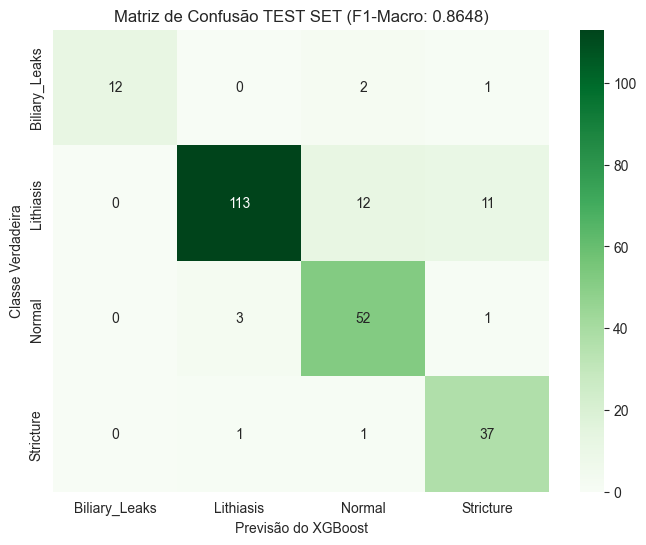

In [18]:
# ==============================================================================
# FASE FINAL: AVALIAÇÃO OFICIAL NO TEST SET
# ==============================================================================
print("A extrair features do conjunto de TESTE (Test Set)...")
X_test, y_test = extract_features(test_loader, model, device)

# Fazer previsões com o XGBoost já treinado
y_pred_test = best_xgb_model.predict(X_test)

# Calcular F1-Score Macro no Test Set
f1_macro_test = f1_score(y_test, y_pred_test, average='macro')
print(f"\n==================================================")
print(f" 🏆 F1-SCORE MACRO (TEST SET OFICIAL): {f1_macro_test:.4f} ")
print(f"==================================================\n")

print("Relatório de Classificação Detalhado (Test Set):")
print(classification_report(y_test, y_pred_test, target_names=nomes_classes))

# Desenhar a Matriz de Confusão Final
cm_test = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', xticklabels=nomes_classes, yticklabels=nomes_classes)
plt.ylabel('Classe Verdadeira')
plt.xlabel('Previsão do XGBoost')
plt.title(f'Matriz de Confusão TEST SET (F1-Macro: {f1_macro_test:.4f})')
plt.show()

A gerar o mapa de oclusão (a deslizar o quadrado pela imagem)...


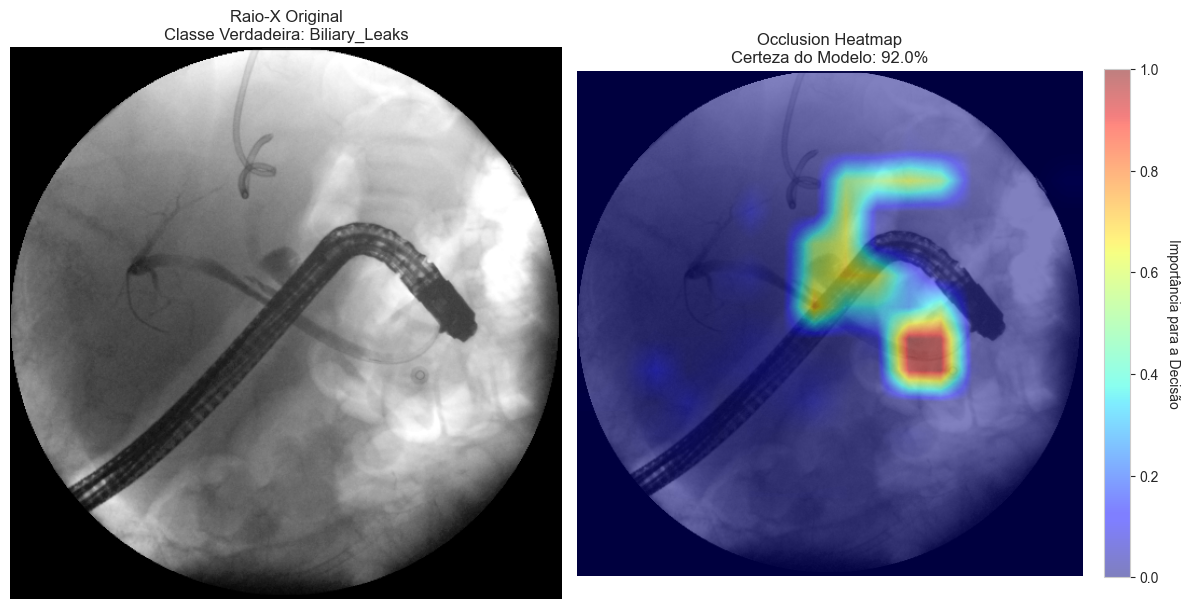

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. FUNÇÃO DE OCLUSÃO PARA MODELOS HÍBRIDOS
# ==============================================================================
def hybrid_occlusion_heatmap(image_tensor, label_idx, cnn_model, xgb_model, patch_size=32, stride=16):
    cnn_model.eval()
    _, C, H, W = image_tensor.shape
    
    # 1. Probabilidade Base (sem nada tapado)
    with torch.no_grad():
        baseline_feat = cnn_model(image_tensor).cpu().numpy()
    baseline_prob = xgb_model.predict_proba(baseline_feat)[0, label_idx]
    
    # 2. Preparar a grelha do mapa de calor
    grid_h, grid_w = (H // stride), (W // stride)
    heatmap = np.zeros((grid_h, grid_w))
    
    print("A gerar o mapa de oclusão (a deslizar o quadrado pela imagem)...")
    
    # 3. Deslizar o quadrado preto pela imagem
    for i in range(grid_h):
        for j in range(grid_w):
            y1, y2 = i * stride, min(i * stride + patch_size, H)
            x1, x2 = j * stride, min(j * stride + patch_size, W)
            
            # Criar a imagem com a zona tapada (zeros = preto)
            occluded_img = image_tensor.clone()
            occluded_img[:, :, y1:y2, x1:x2] = 0.0 
            
            # Extrair features da imagem tapada e ver a nova probabilidade
            with torch.no_grad():
                feat = cnn_model(occluded_img).cpu().numpy()
            prob = xgb_model.predict_proba(feat)[0, label_idx]
            
            # A importância desta zona é o quanto a probabilidade CAIU
            heatmap[i, j] = baseline_prob - prob
            
    # 4. Redimensionar o mapa de calor para o tamanho da imagem original
    heatmap = torch.tensor(heatmap).unsqueeze(0).unsqueeze(0) 
    heatmap_resized = F.interpolate(heatmap, size=(H, W), mode='bilinear', align_corners=False)
    heatmap_resized = heatmap_resized.squeeze().numpy()
    
    # Normalizar (ignorar zonas que não importam e escalar de 0 a 1)
    heatmap_resized = np.maximum(heatmap_resized, 0)
    if np.max(heatmap_resized) > 0:
        heatmap_resized /= np.max(heatmap_resized)
        
    return heatmap_resized, baseline_prob

# ==============================================================================
# 2. SELECIONAR UMA IMAGEM DE TESTE E GERAR A VISUALIZAÇÃO
# ==============================================================================
# Vamos buscar a primeira imagem do Test Loader (podes rodar para outras imagens depois)
images, labels = next(iter(test_loader))
img_tensor = images[0:1].to(device)
true_label = labels[0].item()
nome_da_doenca = nomes_classes[true_label]

# Gerar o Heatmap
heatmap, prob_base = hybrid_occlusion_heatmap(img_tensor, true_label, model, best_xgb_model, patch_size=64, stride=32)

# Desfazer a normalização da imagem para conseguirmos visualizá-la corretamente
img_display = img_tensor.squeeze().cpu().numpy().transpose(1, 2, 0)
img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min())

# ==============================================================================
# 3. DESENHAR O RESULTADO
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Imagem Original
axes[0].imshow(img_display)
axes[0].set_title(f"Raio-X Original\nClasse Verdadeira: {nome_da_doenca}")
axes[0].axis('off')

# Imagem + Mapa de Calor
axes[1].imshow(img_display)
# Sobrepor o heatmap (usamos o colormap 'jet' que vai do azul ao vermelho escuro)
im = axes[1].imshow(heatmap, cmap='jet', alpha=0.5) 
axes[1].set_title(f"Occlusion Heatmap\nCerteza do Modelo: {prob_base*100:.1f}%")
axes[1].axis('off')

# Adicionar a barra de cores
cbar = plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
cbar.set_label('Importância para a Decisão', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

A gerar mapas de calor para 4 imagens. Pode demorar uns segundos...
A gerar o mapa de oclusão (a deslizar o quadrado pela imagem)...


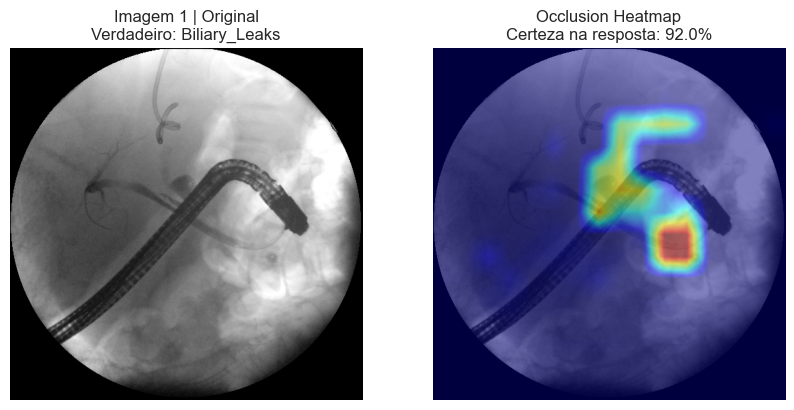

--------------------------------------------------------------------------------
A gerar o mapa de oclusão (a deslizar o quadrado pela imagem)...


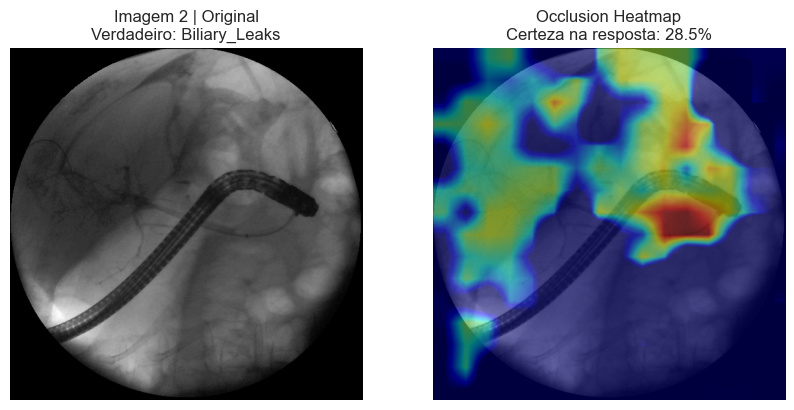

--------------------------------------------------------------------------------
A gerar o mapa de oclusão (a deslizar o quadrado pela imagem)...


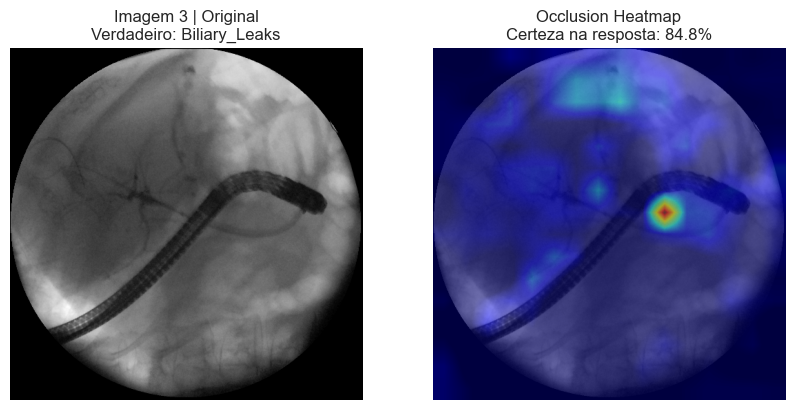

--------------------------------------------------------------------------------
A gerar o mapa de oclusão (a deslizar o quadrado pela imagem)...


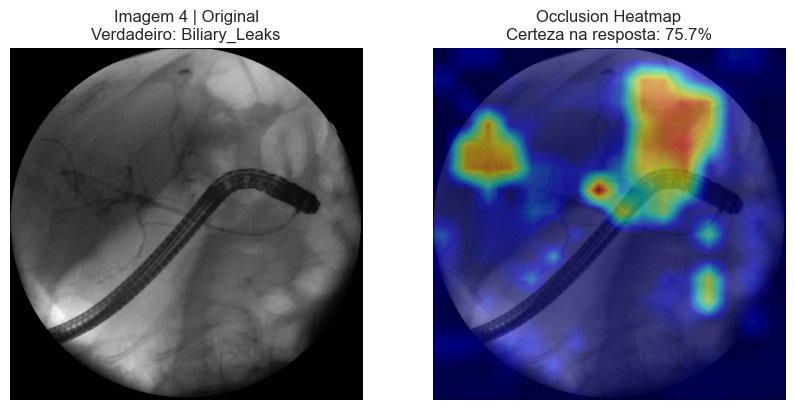

--------------------------------------------------------------------------------


In [23]:
# ==============================================================================
# GALERIA DE HEATMAPS (Ver Várias Imagens)
# ==============================================================================
# 1. Carregar um lote inteiro de imagens de teste
images, labels = next(iter(test_loader))

# 2. Define quantas imagens queres ver deste lote (ex: as primeiras 5)
num_imagens_a_ver = 5

num_imagens_no_lote = len(labels)

limite = min(num_imagens_a_ver, num_imagens_no_lote)

print(f"A gerar mapas de calor para {limite} imagens. Pode demorar uns segundos...")

for i in range(limite):
    # Agarrar na imagem 'i'
    img_tensor = images[i:i+1].to(device)
    true_label = labels[i].item()
    nome_da_doenca = nomes_classes[true_label]

    # Gerar o Heatmap
    heatmap, prob_base = hybrid_occlusion_heatmap(img_tensor, true_label, model, best_xgb_model, patch_size=64, stride=32)

    # Preparar a imagem original para visualização
    img_display = img_tensor.squeeze().cpu().numpy().transpose(1, 2, 0)
    img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min())

    # ==========================================================================
    # DESENHAR O PAR DE IMAGENS
    # ==========================================================================
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    # Original
    axes[0].imshow(img_display)
    axes[0].set_title(f"Imagem {i+1} | Original\nVerdadeiro: {nome_da_doenca}")
    axes[0].axis('off')

    # Mapa de Calor
    axes[1].imshow(img_display)
    im = axes[1].imshow(heatmap, cmap='jet', alpha=0.5) 
    axes[1].set_title(f"Occlusion Heatmap\nCerteza na resposta: {prob_base*100:.1f}%")
    axes[1].axis('off')

    plt.show() # Mostra o gráfico e passa para a próxima imagem do loop
    print("-" * 80) # Linha separadora para ficar bonito

## Training
The `train_model` function runs the training loop with optional early stopping, learning rate scheduling and logging of metrics (F1, AUC). Parameters and training logic are unchanged.

In [ ]:

def train_model(train_dl, val_dl, model, loss_function, optimizer, epochs, name):
    early_stopping_patience = 10
    epochs_without_improvement = 0
    liveloss = PlotLosses(outputs=[MatplotlibPlot(figpath=f"{name}.png")])
    best_metric = -1
    best_metric_epoch = -1
    metric_values = list()

    # F1 metric
    f1_metric = MulticlassF1Score(num_classes=num_class, average='macro').to(device)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs) 

    for epoch in range(epochs):
        logs = {}
        model.train()
        epoch_loss = 0
        running_loss = 0.0
        running_corrects = 0.0
        y_pred_train = torch.tensor([], dtype=torch.float32, device=device)
        y_train = torch.tensor([], dtype=torch.long, device=device)

        for inputs, labels in train_dl:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            #outputs = torch.softmax(outputs, dim=1)
            loss = loss_function(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.detach() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)
            y_pred_train = torch.cat([y_pred_train, outputs], dim=0)
            y_train = torch.cat([y_train, labels], dim=0)

        epoch_loss = running_loss / len(train_dl.dataset)
        epoch_acc = running_corrects.float() / len(train_dl.dataset)

        # Compute F1-score on training set
        pred_train_labels = y_pred_train.argmax(dim=1)
        f1_train_value = f1_metric(pred_train_labels, y_train)

        logs['loss'] = epoch_loss.item()
        logs['accuracy'] = epoch_acc.item()
        logs['F1'] = f1_train_value.item()  # Train F1

        # Validation phase
        model.eval()
        running_loss = 0.0
        running_corrects = 0.0
        y_pred = torch.tensor([], dtype=torch.float32, device=device)
        y = torch.tensor([], dtype=torch.long, device=device)

        with torch.no_grad():
            for val_images, val_labels in val_dl:
                val_images = val_images.to(device)
                val_labels = val_labels.to(device)
                outputs = model(val_images)
                #outputs = torch.softmax(outputs, dim=1)
                loss = loss_function(outputs, val_labels)
                running_loss += loss.detach() * val_images.size(0)
                _, preds = torch.max(outputs, 1)
                running_corrects += torch.sum(preds == val_labels.data)
                y_pred = torch.cat([y_pred, outputs], dim=0)
                y = torch.cat([y, val_labels], dim=0)

            epoch_loss = running_loss / len(val_dl.dataset)
            epoch_acc = running_corrects.float() / len(val_dl.dataset)
            logs['val_loss'] = epoch_loss.item()
            logs['val_accuracy'] = epoch_acc.item()

            # Compute F1-score on validation set
            pred_labels = y_pred.argmax(dim=1)
            f1_score_value = f1_metric(pred_labels, y)
            logs['val_F1'] = f1_score_value.item()

            y_onehot = [to_onehot(i) for i in decollate_batch(y, detach=False)]
            y_pred_act = [act(i) for i in decollate_batch(y_pred)]
            auc_metric(y_pred_act, y_onehot)
            result = auc_metric.aggregate()
            auc_metric.reset()
            del y_pred_act, y_onehot
            metric_values.append(result)

            if f1_score_value > best_metric:
                best_metric = f1_score_value
                best_metric_epoch = epoch + 1
                best_train_f1 = f1_train_value.item()   
                torch.save(model.state_dict(), name)
                print('saved new best metric model')
                epochs_without_improvement = 0  # reset counter
            else:
                epochs_without_improvement += 1
            
            if epochs_without_improvement >= early_stopping_patience:
                print(
                    f"Early stopping at epoch {epoch + 1} \n"
                    f" Best Val F1: {best_metric:.4f} \n"
                    f" Best Train F1: {best_train_f1:.4f} \n"
                    f" current Val F1: {f1_score_value:.4f} \n"
                    f" current Train F1: {f1_train_value:.4f} \n"
                    f" Best epoch: {best_metric_epoch} \n"
                )
                break
            print(
                f"current epoch: {epoch + 1} current AUC: {result:.4f}"
                f" current F1 (train): {f1_train_value:.4f}"
                f" current F1 (val): {f1_score_value:.4f}"
                f" best AUC: {best_metric:.4f}"
                f" at epoch: {best_metric_epoch}"
            )
        
        logs['val_AUC'] = result
        liveloss.update(logs)
        liveloss.send()

        scheduler.step() 

    print(f"train completed, best_metric: {best_metric:.4f} at epoch: {best_metric_epoch}")


In [ ]:
EPOCHS = 60
LEARNING_RATE = 1e-4

from monai.losses import FocalLoss
loss_function = FocalLoss(to_onehot_y=True)

optimizer = torch.optim.Adam(model.parameters(), LEARNING_RATE)

val_interval = 1
auc_metric = ROCAUCMetric()

device = torch.device("cuda")
starttime = time.perf_counter()
train_model(train_loader, val_loader, model, loss_function, optimizer, EPOCHS, model_name)
endtime = time.perf_counter()
print(f"Time elapsed: {endtime - starttime} seconds")

## Evaluation
Evaluate the model on the test set, compute F1/accuracy and plot a confusion matrix. The following cells perform inference and generate the final metrics and plots.

In [ ]:
def evaluate_model(test_dl, model):
    predictions = list()
    actual_values = list()
    for inputs, labels in test_dl:
        # evaluate the model on the test set
        inputs = inputs.to(device)
        labels = labels.to(device)
        yprev = model(inputs)
        yprev = yprev.detach().cpu().numpy()
        actual = labels.cpu().numpy()
        yprev = np.argmax(yprev, axis=1)
        actual = actual.reshape((len(actual), 1))
        yprev = yprev.reshape((len(yprev), 1))
        predictions.append(yprev)
        actual_values.append(actual)
    predictions, actual_values = np.vstack(predictions), np.vstack(actual_values)
    
    # Compute F1-score
    f1 = f1_score(actual_values, predictions, average='macro')  # Can be 'micro', 'macro' or 'weighted'
    print(f"F1 Score: {f1:0.4f}")
    
    return actual_values, predictions

def display_predictions(actual_values, predictions):
    right = 0
    wrong = 0
    primeiros = 0
    i = 0
    for r, p in zip(actual_values, predictions):
        if primeiros < 20:
            print(f'true: {r} pred: {p}')
            primeiros += 1
        if r == p:
            right += 1
        else:
            wrong += 1
        i += 1
        if i > 10:
            break

    # Compute accuracy
    corrects = np.sum(predictions == actual_values)
    acc = corrects / len(test_loader.dataset)
    acc = accuracy_score(actual_values, predictions)
    print(f'Accuracy: {acc:0.3f}\n')
    print(f'correct: {right} incorrect: {wrong}')
    acc = accuracy_score(actual_values, predictions)
    print(f'Accuracy: {acc:0.3f}\n')
    print(f'correct: {right} incorrect: {wrong}')

    # Compute F1-score
    f1 = f1_score(actual_values, predictions, average='macro')
    print(f"F1 Score: {f1:0.4f}")

def display_confusion_matrix(cm, list_classes, filename):
    plt.figure(figsize=(16, 8))
    sns.heatmap(cm, annot=True, xticklabels=list_classes, yticklabels=list_classes, annot_kws={"size": 12}, fmt='g', linewidths=.5)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.savefig(f"{filename}_cm.png", dpi=300)
    plt.show()

# Load trained model
model.load_state_dict(torch.load('./' + model_name))
model.eval()

# Evaluate the model
actual_values, predictions = evaluate_model(test_loader, model)

# Display the predictions
display_predictions(actual_values, predictions)

# Classification report
print(classification_report(actual_values, predictions, target_names=class_names, digits=4, zero_division=0))

# Confusion Matrix
cr = classification_report(actual_values, predictions, target_names=class_names, output_dict=True)
list_classes = [cls for cls in cr.keys() if cls in class_names]

cm = confusion_matrix(actual_values, predictions)

print(cm)
display_confusion_matrix(cm, list_classes, model_name)